# Attention From Scratch

In [1]:
import numpy as np

Q = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
], dtype=float)

K = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
], dtype=float)

V = np.array([
    [10, 0],
    [0, 10],
    [5, 5]
], dtype=float)

scores = Q @ K.T

print("Attention Scores:")
print(scores)

Attention Scores:
[[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]


# Softmax

In [2]:
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

attention_weights = softmax(scores)

print("Attention Weights:")
print(attention_weights)

Attention Weights:
[[0.4223188  0.1553624  0.4223188 ]
 [0.1553624  0.4223188  0.4223188 ]
 [0.21194156 0.21194156 0.57611688]]


# Apply Attention to Values

In [3]:
context = attention_weights @ V

print("Context:")
print(context)

Context:
[[6.33478197 3.66521803]
 [3.66521803 6.33478197]
 [5.         5.        ]]


- Q
↓
Q × Kᵀ
↓
Attention Scores
↓
Softmax
↓
Attention Weights
↓
Weights × V
↓
Context

# Scaled Dot-Product Attention

d_k = K.shape[-1]

scores = (Q @ K.T) / np.sqrt(d_k)

attention_weights = softmax(scores)

context = attention_weights @ V

print("Scores:")
print(scores)

print("\nWeights:")
print(attention_weights)

print("\nContext:")
print(context)

# Causal / Masked Attention

In [6]:
Q = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
], dtype=float)

K = Q.copy()

V = np.array([
    [10, 0],
    [0, 10],
    [5, 5]
], dtype=float)

scores = (Q @ K.T) / np.sqrt(K.shape[-1])

mask = np.triu(
    np.ones_like(scores),
    k=1
)

scores = np.where(mask == 1, -np.inf, scores)

print(scores)

[[0.70710678       -inf       -inf]
 [0.         0.70710678       -inf]
 [0.70710678 0.70710678 1.41421356]]


# Softmax after mask

In [8]:
attention_weights = softmax(scores)

print(attention_weights)

[[1.         0.         0.        ]
 [0.33023845 0.66976155 0.        ]
 [0.24825508 0.24825508 0.50348984]]


# Positional Encoding

In [9]:
import numpy as np

def positional_encoding(seq_len, d_model):
    pe = np.zeros((seq_len, d_model))

    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = np.sin(
                pos / (10000 ** (i / d_model))
            )

            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(
                    pos / (10000 ** (i / d_model))
                )

    return pe

In [10]:
pe = positional_encoding(
    seq_len=5,
    d_model=6
)

print(pe)

[[ 0.          1.          0.          1.          0.          1.        ]
 [ 0.84147098  0.54030231  0.04639922  0.99892298  0.00215443  0.99999768]
 [ 0.90929743 -0.41614684  0.0926985   0.99569422  0.00430886  0.99999072]
 [ 0.14112001 -0.9899925   0.1387981   0.9903207   0.00646326  0.99997911]
 [-0.7568025  -0.65364362  0.18459872  0.98281398  0.00861763  0.99996287]]


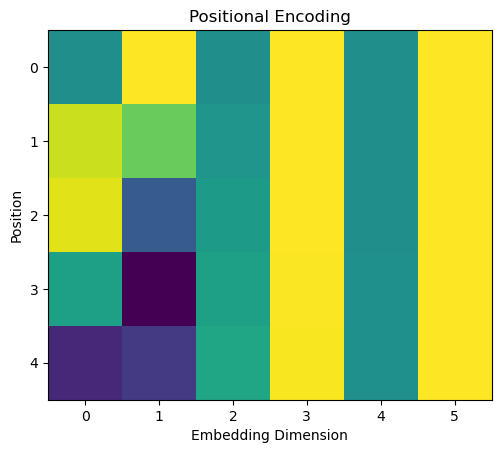

In [11]:
import matplotlib.pyplot as plt

plt.imshow(pe)
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Positional Encoding")
plt.show()

# Multi-Head Attention — PyTorch

In [12]:
import torch
import torch.nn as nn

embed_dim = 8
num_heads = 2

attention = nn.MultiheadAttention(
    embed_dim=embed_dim,
    num_heads=num_heads,
    batch_first=True
)

x = torch.randn(1, 5, embed_dim)

output, weights = attention(
    x,
    x,
    x
)

print("Input shape:", x.shape)
print("Output shape:", output.shape)
print("Attention weights shape:", weights.shape)

Input shape: torch.Size([1, 5, 8])
Output shape: torch.Size([1, 5, 8])
Attention weights shape: torch.Size([1, 5, 5])


# Residual Connection

In [14]:
x = torch.randn(1, 5, 8)

attention_output = torch.randn(1, 5, 8)

result = x + attention_output

print("Input shape:", x.shape)
print("Output shape:", result.shape)

Input shape: torch.Size([1, 5, 8])
Output shape: torch.Size([1, 5, 8])


Input
  ├───────────────┐
  ↓               │
Attention          +
  ↓               │
Output ────────────┘

# Layer Normalization

In [ ]:
layer_norm = nn.LayerNorm(8)

x = torch.randn(1, 5, 8)

normalized = layer_norm(x)

print(normalized.shape)

In [15]:
layer_norm = nn.LayerNorm(8)

x = torch.randn(1, 5, 8)

normalized = layer_norm(x)

print(normalized.shape)

torch.Size([1, 5, 8])


# Simple Transformer Encoder

In [ ]:
encoder_layer = nn.TransformerEncoderLayer(
    d_model=8,
    nhead=2,
    batch_first=True
)

transformer_encoder = nn.TransformerEncoder(
    encoder_layer,
    num_layers=2
)

x = torch.randn(1, 5, 8)

output = transformer_encoder(x)

print("Input:", x.shape)
print("Output:", output.shape)